In [1]:
import pandas as pd

In [3]:
df = pd.read_csv(r'/content/SalesRecords.csv')
df.columns

Index(['Region', 'Country', 'Item Type', 'Sales Channel', 'Order Priority',
       'Order Date', 'Order ID', 'Ship Date', 'Units Sold', 'Unit Price',
       'Unit Cost', 'Total Revenue', 'Total Cost', 'Total Profit'],
      dtype='object')

In [4]:
df.head()

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
0,Australia and Oceania,Tuvalu,Baby Food,Offline,H,5/28/2010,669165933,6/27/2010,9925,255.28,159.42,2533654.00,1582243.50,951410.50
1,Central America and the Caribbean,Grenada,Cereal,Online,C,8/22/2012,963881480,9/15/2012,2804,205.70,117.11,576782.80,328376.44,248406.36
2,Europe,Russia,Office Supplies,Offline,L,5/2/2014,341417157,5/8/2014,1779,651.21,524.96,1158502.59,933903.84,224598.75
3,Sub-Saharan Africa,Sao Tome and Principe,Fruits,Online,C,6/20/2014,514321792,7/5/2014,8102,9.33,6.92,75591.66,56065.84,19525.82
4,Sub-Saharan Africa,Rwanda,Office Supplies,Offline,L,2/1/2013,115456712,2/6/2013,5062,651.21,524.96,3296425.02,2657347.52,639077.50


In [5]:
df.dtypes

,0
Region,object
Country,object
Item Type,object
Sales Channel,object
Order Priority,object
Order Date,object
Order ID,int64
Ship Date,object
Units Sold,int64
Unit Price,float64


In [7]:
df1 = df.groupby('Region') ['Units Sold'].sum().reset_index()
df1

,Region,Units Sold
0,Asia,59967
1,Australia and Oceania,68325
2,Central America and the Caribbean,35771
3,Europe,98117
4,Middle East and North Africa,48678
5,North America,19143
6,Sub-Saharan Africa,182870


In [9]:
total_units = df1['Units Sold'].sum()
df1['Percentage'] = (df1['Units Sold'] / total_units) * 100
df1

,Region,Units Sold,Percentage
0,Asia,59967,11.692414
1,Australia and Oceania,68325,13.322063
2,Central America and the Caribbean,35771,6.974658
3,Europe,98117,19.130932
4,Middle East and North Africa,48678,9.491276
5,North America,19143,3.732518
6,Sub-Saharan Africa,182870,35.656140


In [11]:
!pip install squarify

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
import squarify

In [23]:
def get_color(name, number):
  pal = list (sns.color_palette(palette=name, n_colors=number).as_hex())
  return pal

In [24]:
pal_vi = get_color('viridis_r', len(df1))
pal_plas = get_color('plasma_r', len(df1))
pal_spec = get_color('Spectral', len(df1))
pal_hsv = get_color('hsv', len(df1))

In [21]:
colNm1 = 'Region'; colNm2 = 'Units Sold'
col1 =df1[colNm1]; col2 = df1[colNm2]

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Asia'),
  Text(1, 0, 'Australia and Oceania'),
  Text(2, 0, 'Central America and the Caribbean'),
  Text(3, 0, 'Europe'),
  Text(4, 0, 'Middle East and North Africa'),
  Text(5, 0, 'North America'),
  Text(6, 0, 'Sub-Saharan Africa')])

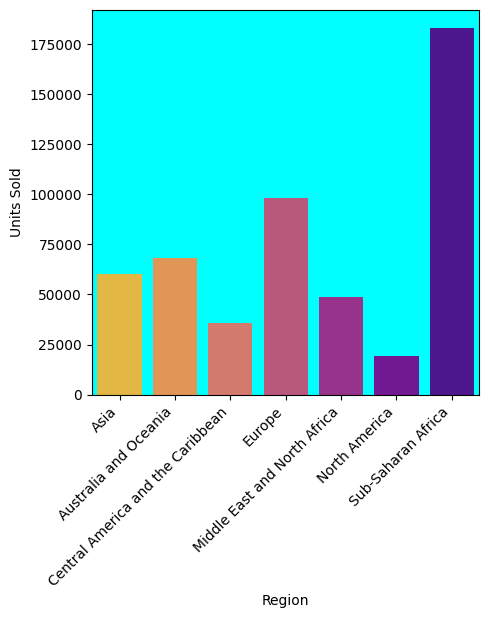

In [25]:
fiq, ax = plt.subplots(figsize=(5,5))
ax = sns.barplot(data=df1, x=colNm1, y=colNm2, hue=colNm1, errorbar=None, palette=pal_plas)

ax.set_facecolor('#00FFFF')

plt.xticks(rotation=45, ha='right')

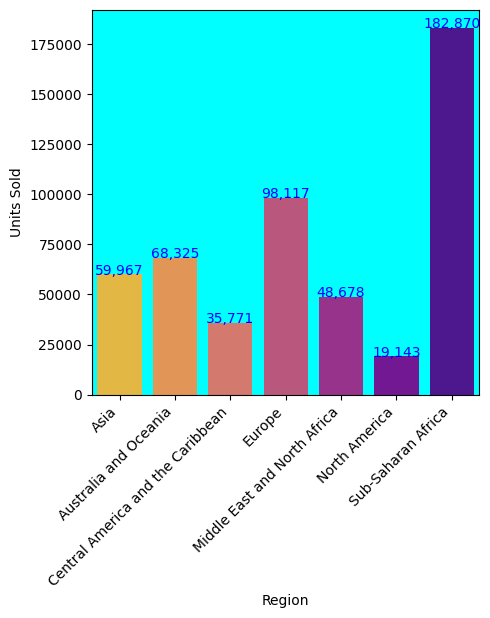

In [28]:
fig, ax = plt.subplots(figsize=(5,5))

ax = sns.barplot(data=df1, x=colNm1, y=colNm2,
                 hue=colNm1, errorbar=None, palette=pal_plas)

ax.set_facecolor('#00FFFF')

plt.xticks(rotation=45, ha='right')

for index, row in df1.iterrows():
    formatted_value = f"{row[colNm2]:,.0f}"
    ax.text(index, row[colNm2] + 50,
            formatted_value, color='blue', ha='center')



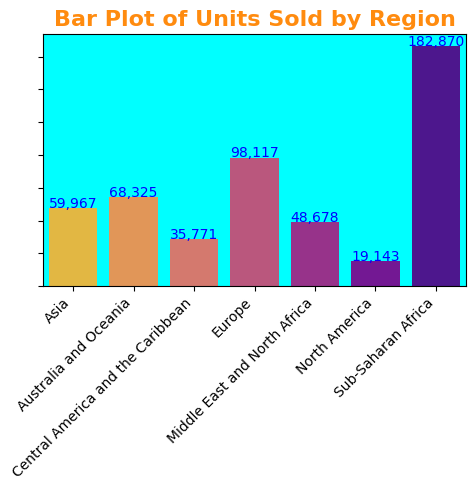

In [29]:
fig, ax = plt.subplots(figsize=(5,5))

ax = sns.barplot(data=df1, x=colNm1, y=colNm2,
                 hue=colNm1, errorbar=None, palette=pal_plas)

ax.set_facecolor('#00FFFF')

plt.xticks(rotation=45, ha='right')

for index, row in df1.iterrows():
    formatted_value = f"{row[colNm2]:,.0f}"
    ax.text(index, row[colNm2] + 50,
            formatted_value, color='blue', ha='center')

ax.set_title(f"Bar Plot of {colNm2} by {colNm1}", color="#FF8B0F", fontdict={'fontsize':16, 'fontweight':'bold'})
ax.set(xlabel=None, ylabel=None)

ax.set_yticklabels([])

plt.tight_layout()
plt.show()


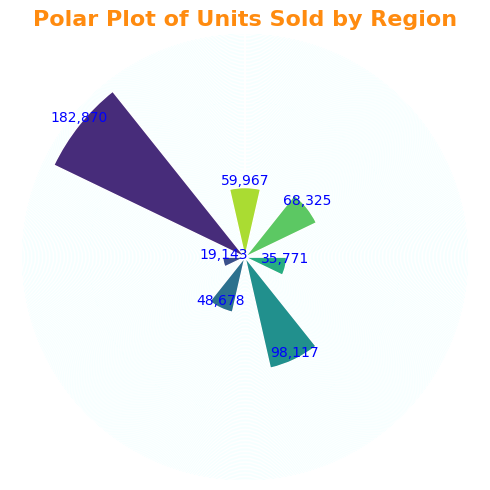

In [30]:
# 2. Polar Bar Chart
# Create a figure
fig, ax = plt.subplots(figsize=(5, 5))
ax.axis("off")
sns.set_style('darkgrid')
ax = plt.subplot(projection='polar')

# Add a light gray background to the polar chart to make it appear circular
ax.set_facecolor('#00FFFF')

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_rlabel_position(0)
ax.set_thetagrids([])
ax.set_rgrids(np.arange(0, col2.max() * 1.1, 500), labels=[])
ax.set_title(f"Polar Plot of {colNm2} by {colNm1}", color="#FF8B0F", fontdict={'fontsize': 16, 'fontweight': 'bold'})
#ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=2, title="Region")
# Loop through the data to plot bars and add labels
for i, (units, region) in enumerate(zip(col2, col1)):
    # Calculate the angle for the current bar
    angle = i * 2 * np.pi / len(df1)
    # Draw the bar
    ax.bar(
        x=angle, height=units, width=2 * np.pi / (len(df1) * 2),
        label=region, color=pal_vi[i])

    # --- Add the data label for the polar chart ---
    # The label needs to be positioned slightly outside the bar.
    # The 'y' coordinate in a polar plot is the radius. We use the 'units' value
    # plus a small offset (e.g., 50) to place the text.
    # The 'x' coordinate is the angle.
    formatted_value = f"{units:,.0f}"
    ax.text(
        x=angle,          # Angle of the bar
        y=units + 50,     # Radius (height of the bar + a small offset)
        s=formatted_value,  # The text to display
        ha='center',      # Horizontal alignment
        va='bottom',      # Vertical alignment
        color='blue'
    )

# Adjust layout to prevent titles from overlapping
plt.tight_layout()
plt.show()